# Crop Yield Prediction Project:
## Predictive Analytics of Corn Production via Regression Modeling
### Author: Shannon McFarland
### Last Modified: 8/10/24

<hr style="border:2px solid black">

## Part 1: Exploratory Data Analysis (EDA)

In [3]:
# Import necessary libraries
import pandas as pd
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
# Load India crop and weather data sets
crop_df = pd.read_csv("crop_yield_data.csv")
weather_df = pd.read_csv("India_weather_data.csv")

### 1a. Corn Data Set Exploration:

In [7]:
crop_df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
1,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
2,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
3,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
4,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
...,...,...,...,...,...,...,...,...,...,...
15967,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
15968,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
15969,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
15970,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667


In [9]:
# Determine how many missing values are in each column
crop_df.isna().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [11]:
# Filter data for only corn
filter_crop = crop_df[crop_df["Crop"].isin(["Maize"])]
filter_crop.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
6,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652
30,Maize,1997,Kharif,Karnataka,502797.0,1391132,1266.7,47851190.49,155867.07,2.687778
31,Maize,1997,Rabi,Karnataka,48844.0,98932,1266.7,4648483.48,15141.64,1.980000
32,Maize,1997,Summer,Karnataka,9730.0,20893,1266.7,926004.10,3016.30,2.165714
47,Maize,1997,Kharif,Meghalaya,17175.0,24878,3818.2,1634544.75,5324.25,1.444286


In [13]:
# Check for years which are represented in data set
filter_crop["Crop_Year"].unique()

array([1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020])

In [15]:
# Count of the different seasons represented in data set 
filter_crop["Season"].value_counts()

Kharif         514
Rabi           218
Summer         143
Autumn          61
Winter          18
Name: Season, dtype: int64

In [17]:
# Filter data for only kharif and rabi seasons

filter_crop = filter_crop[filter_crop["Season"].isin(["Kharif     ", "Rabi       "])]
filter_crop = filter_crop.replace({"Kharif     ": "Kharif", "Rabi       ": "Rabi"}) # Remove whitespace from kharif and rabi strings
filter_crop.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
6,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652
30,Maize,1997,Kharif,Karnataka,502797.0,1391132,1266.7,47851190.49,155867.07,2.687778
31,Maize,1997,Rabi,Karnataka,48844.0,98932,1266.7,4648483.48,15141.64,1.980000
47,Maize,1997,Kharif,Meghalaya,17175.0,24878,3818.2,1634544.75,5324.25,1.444286
100,Maize,1998,Kharif,Assam,19810.0,13965,2354.4,1957228.00,5744.90,0.608696


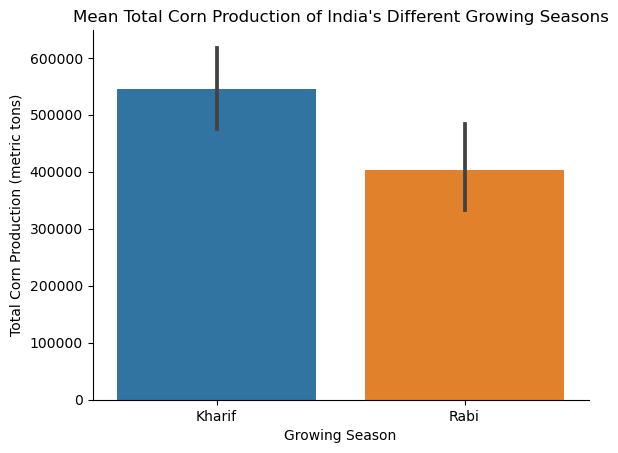

In [23]:
# Seaborn barplot comparing total corn production across India's growing seasons
with warnings.catch_warnings():
    warnings.simplefilter('ignore') # Ignore warning message that appears.
    season_barplot = sns.barplot(x = "Season", y = "Production", data = filter_crop, palette = {"Kharif": "C0", "Rabi": "C1"})
    season_barplot.set(xlabel = "Growing Season", ylabel = "Total Corn Production (metric tons)",
            title = "Mean Total Corn Production of India's Different Growing Seasons")
    sns.despine()
    plt.show()

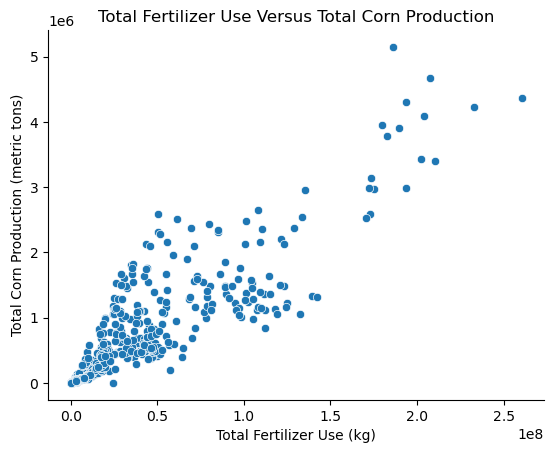

In [25]:
# Scatter plot showcasing relationship between feritlizer use and total corn production in metric tons
import seaborn as sns # data visualization/ graphing library
import matplotlib.pyplot as plt # data visualization/ graphing library

fertilizer_scatterplot = sns.scatterplot(data = filter_crop, x = "Fertilizer",  y = "Production")
fertilizer_scatterplot.set(xlabel = "Total Fertilizer Use (kg)", ylabel = "Total Corn Production (metric tons)",
            title = "Total Fertilizer Use Versus Total Corn Production")
sns.despine()
plt.show()

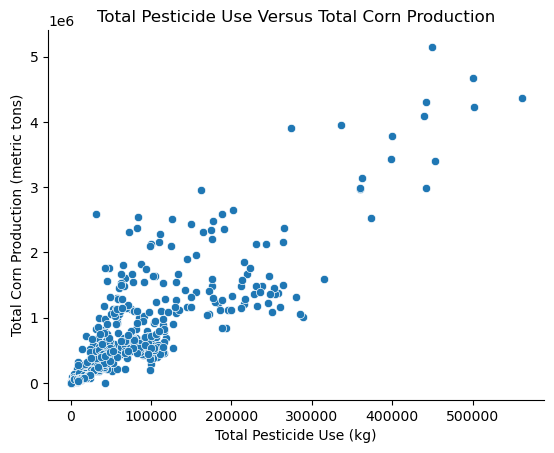

In [27]:
# Scatter plot showcasing relationship between pesticide use and total corn production in metric tons

pesticide_scatterplot = sns.scatterplot(data = filter_crop, x = "Pesticide",  y = "Production")
pesticide_scatterplot.set(xlabel = "Total Pesticide Use (kg)", ylabel = "Total Corn Production (metric tons)",
            title = "Total Pesticide Use Versus Total Corn Production")
sns.despine()
plt.show()

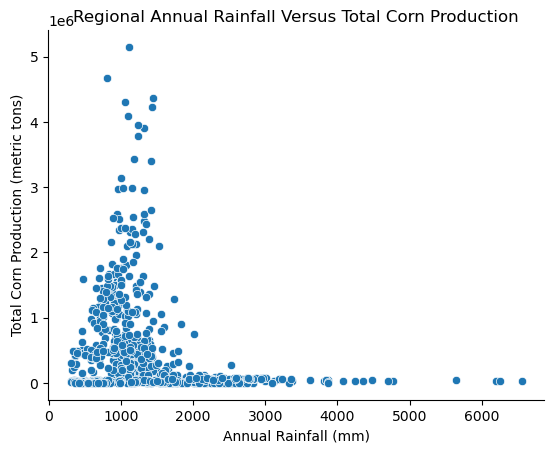

In [33]:
# Scatter plot showcasing relationship between regional annual rainfall and total corn production in metric tons

rainfall_scatterplot = sns.scatterplot(data = filter_crop, x = "Annual_Rainfall",  y = "Production")
rainfall_scatterplot.set(xlabel = "Annual Rainfall (mm)", ylabel = "Total Corn Production (metric tons)",
            title = "Regional Annual Rainfall Versus Total Corn Production")
sns.despine()
plt.show()

### 1b. Weather Data Set Exploration:

In [35]:
weather_df

,Unnamed: 0,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,0,1901,17.99,19.43,23.49,26.41,28.28,28.60,27.49,26.98,26.26,25.08,21.73,18.95
1,1,1902,19.00,20.39,24.10,26.54,28.68,28.44,27.29,27.05,25.95,24.37,21.33,18.78
2,2,1903,18.32,19.79,22.46,26.03,27.93,28.41,28.04,26.63,26.34,24.57,20.96,18.29
3,3,1904,17.77,19.39,22.95,26.73,27.83,27.85,26.84,26.73,25.84,24.36,21.07,18.84
4,4,1905,17.40,17.79,21.78,24.84,28.32,28.69,27.67,27.47,26.29,26.16,22.07,18.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,112,2013,18.88,21.07,24.53,26.97,29.06,28.24,27.50,27.22,26.87,25.63,22.18,19.69
113,113,2014,18.81,20.35,23.34,26.91,28.45,29.42,28.07,27.42,26.61,25.38,22.53,19.50
114,114,2015,19.02,21.23,23.52,26.52,28.82,28.15,28.03,27.64,27.04,25.82,22.95,20.21
115,115,2016,20.92,23.58,26.61,29.56,30.41,29.70,28.18,28.17,27.72,26.81,23.90,21.89


In [37]:
# Checking for missing values
weather_df.isna().sum()

Unnamed: 0    0
YEAR          0
JAN           0
FEB           0
MAR           0
APR           0
MAY           0
JUN           0
JUL           0
AUG           0
SEP           0
OCT           0
NOV           0
DEC           0
dtype: int64

In [39]:
weather_df.describe()

,Unnamed: 0,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,58.000000,1959.000000,18.423248,20.137949,23.434188,26.514103,28.386410,28.300940,27.369231,26.940085,26.342650,24.742051,21.765726,19.173333
std,33.919021,33.919021,0.612963,0.900944,0.862825,0.750740,0.644678,0.460603,0.345920,0.348876,0.387789,0.563152,0.634183,0.635912
min,0.000000,1901.000000,17.250000,17.790000,21.780000,24.840000,26.970000,27.330000,26.480000,26.210000,25.470000,23.520000,20.590000,17.980000
25%,29.000000,1930.000000,18.070000,19.470000,22.840000,26.000000,27.950000,28.020000,27.150000,26.730000,26.110000,24.390000,21.320000,18.780000
50%,58.000000,1959.000000,18.350000,19.990000,23.330000,26.540000,28.340000,28.250000,27.340000,26.900000,26.310000,24.670000,21.720000,19.180000
75%,87.000000,1988.000000,18.720000,20.550000,23.930000,26.910000,28.820000,28.580000,27.530000,27.150000,26.500000,24.920000,22.150000,19.550000
max,116.000000,2017.000000,20.920000,23.580000,26.610000,29.560000,30.780000,29.880000,28.470000,28.170000,28.110000,27.240000,23.920000,21.890000


<hr style="border:2px solid black">

## Part 2a: Data Preparation - Weather Data Set

In [41]:
clean_weather = weather_df.drop("Unnamed: 0", axis = 1) # Remove unnamed column
clean_weather = clean_weather[(clean_weather["YEAR"] >= 1996)] # Filter for years only present in crop data set (ex. 1996 - 2017)
clean_weather["YEAR"].unique()

array([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017])

In [43]:
# Yearly Mean Kharif Temperature Calculations for Sowing, and Growing, and Harvesting Time Periods

kharif_temp = clean_weather # Create separate kharif dataframe
kharif_temp["Sown_Temp"] = kharif_temp[["JUN", "JUL"]].mean(axis = 1) # Mean Sowing temp
kharif_temp["Growing_Temp"] = kharif_temp[["JUL", "AUG", "SEP"]].mean(axis = 1) # Mean Growing temp
kharif_temp["Harvest_Temp"] = kharif_temp[["SEP", "OCT"]].mean(axis = 1) # Mean Harvesting temp
kharif_temp = kharif_temp.drop(labels = 95, axis = 0) # Drop 1996 year since not needed for kharif temp calculations unlike rabi
kharif_temp["Season"] = "Kharif" # Create column with string Kharif label
kharif_temp = kharif_temp[["YEAR", "Season", "Sown_Temp", "Growing_Temp", "Harvest_Temp"]] # Drop month columns
kharif_temp.rename(columns = {"YEAR": "Year"}, inplace = True) # Rename Year column
kharif_temp.head()

,Year,Season,Sown_Temp,Growing_Temp,Harvest_Temp
96,1997,Kharif,28.170,27.363333,25.645
97,1998,Kharif,28.330,27.300000,25.985
98,1999,Kharif,27.765,27.186667,25.935
99,2000,Kharif,27.680,26.950000,26.055
100,2001,Kharif,27.880,27.370000,26.175


In [45]:
# Yearly Mean Rabi Temperature Calculations for Sowing, and Growing, and Harvesting Time Periods

rabi_temp = clean_weather # Create separate rabi dataframe
rabi_temp["Sown_Temp"] = rabi_temp[["OCT", "NOV", "DEC"]].mean(axis = 1) # Mean Sowing temp
rabi_temp["Growing_Temp"] = rabi_temp[["JAN", "FEB", "MAR", "APR"]].mean(axis = 1) # Mean Growing temp
rabi_temp["Harvest_Temp"] = rabi_temp[["APR", "MAY"]].mean(axis = 1) # Mean Harvesting temp

# Shifts "Sown_Temp" down by one since rabi "Sown_Temp" takes place in the year prior fall/winter. Therefore, the "Sown_Temp", "Growing_Temp"
# ,and "Harvest_Temp" of the same growing season are all in the same row
rabi_temp["Sown_shift"] = rabi_temp['Sown_Temp'].shift(periods=1) 
rabi_temp = rabi_temp.drop(labels = 95, axis = 0) # Drop 1996 year since not needed post rabi temp calculations
rabi_temp["Season"] = "Rabi" # Create column with string rabi label
rabi_temp = rabi_temp[["YEAR", "Season", "Sown_shift", "Growing_Temp", "Harvest_Temp"]] # Drop month columns
rabi_temp.rename(columns = {"YEAR": "Year", "Sown_shift": "Sown_Temp"}, inplace = True) # Rename Year column
rabi_temp.head()

,Year,Season,Sown_Temp,Growing_Temp,Harvest_Temp
96,1997,Rabi,21.756667,21.7325,26.705
97,1998,Rabi,21.946667,22.3550,28.090
98,1999,Rabi,22.320000,22.8550,27.895
99,2000,Rabi,22.290000,22.2850,28.095
100,2001,Rabi,22.663333,22.6300,28.180


In [47]:
# Combined all the kharif and rabi temperature data into one large dataset
combined_weather_df = pd.concat([kharif_temp, rabi_temp], ignore_index=True, axis = 0) # axis = 0 indicates combining dataframes by rows
combined_weather_df.head()

,Year,Season,Sown_Temp,Growing_Temp,Harvest_Temp
0,1997,Kharif,28.170,27.363333,25.645
1,1998,Kharif,28.330,27.300000,25.985
2,1999,Kharif,27.765,27.186667,25.935
3,2000,Kharif,27.680,26.950000,26.055
4,2001,Kharif,27.880,27.370000,26.175


In [53]:
# Pivot dataframe from "wide" to "long" format via melt() function with "Year", "Month", and "Sales" as column headers
melt_df = pd.melt(combined_weather_df, id_vars = (["Year", "Season"])) # Year is used as "key" column/ group indicator
melt_df.rename(columns={"variable": "Temp_Period", "value": "Temperature"}, inplace=True) # Rename column headers
melt_df

,Year,Season,Temp_Period,Temperature
0,1997,Kharif,Sown_Temp,28.170
1,1998,Kharif,Sown_Temp,28.330
2,1999,Kharif,Sown_Temp,27.765
3,2000,Kharif,Sown_Temp,27.680
4,2001,Kharif,Sown_Temp,27.880
...,...,...,...,...
121,2013,Rabi,Harvest_Temp,28.015
122,2014,Rabi,Harvest_Temp,27.680
123,2015,Rabi,Harvest_Temp,27.670
124,2016,Rabi,Harvest_Temp,29.985


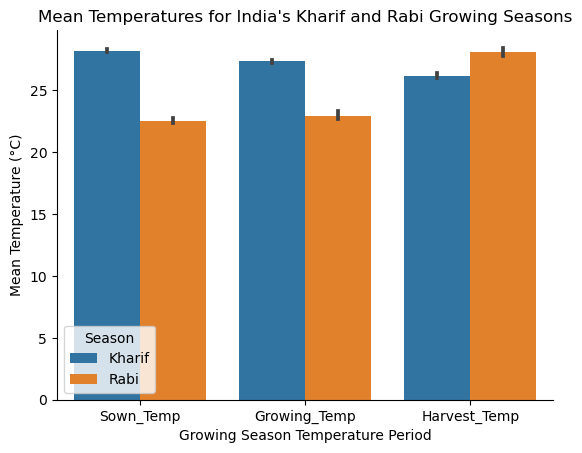

In [59]:
# Bar plot comparing India's mean temperatures for Kharif and Rabi growing seasons
weather_barplot = sns.barplot(x = "Temp_Period", y = "Temperature", data = melt_df, hue = "Season")

weather_barplot.set(xlabel = "Growing Season Temperature Period", ylabel = "Mean Temperature (°C)",
            title = "Mean Temperatures for India's Kharif and Rabi Growing Seasons")
sns.despine()
plt.show()

<hr style="border:2px solid black">

## Part 2b: Data Preparation - Crop Data Set

In [61]:
filter2_crop = filter_crop.drop("Crop", axis = 1) # Remove unnamed column
filter2_crop.rename(columns = {"Crop_Year": "Year"}, inplace = True) # Rename Year column
filter2_crop = filter2_crop[(filter2_crop["Year"] <= 2017)] # Filter for years only present in temperature data set (ex. 1997 - 2017)

In [63]:
# Standardize yield, annual rainfall, fertilizer use, and pesticide use columns by calculating rates via "Area" column
# Area = total land area in hectares used to cultivate crop
filter2_crop["Yield/Ha"] = filter2_crop["Production"]/ filter2_crop["Area"] # Production rate 
filter2_crop["Rainfall/Ha"] = filter2_crop["Annual_Rainfall"]/ filter2_crop["Area"] # Annual rainfall per hectare
filter2_crop["Fertilizer/Ha"] = filter2_crop["Fertilizer"]/ filter2_crop["Area"] # Fertilizer use rate
filter2_crop["Pesticide/Ha"] = filter2_crop["Pesticide"]/ filter2_crop["Area"] # Pesticide use rate

clean_crop = filter2_crop[["Year", "Season", "Yield/Ha", "Rainfall/Ha", "Fertilizer/Ha", "Pesticide/Ha"]]
clean_crop

,Year,Season,Yield/Ha,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha
6,1997,Kharif,0.766080,0.106755,95.17,0.31
30,1997,Kharif,2.766787,0.002519,95.17,0.31
31,1997,Rabi,2.025469,0.025934,95.17,0.31
47,1997,Kharif,1.448501,0.222311,95.17,0.31
100,1998,Kharif,0.704947,0.118849,98.80,0.29
...,...,...,...,...,...,...
15481,2014,Kharif,1.562500,0.050067,150.96,0.33
15485,2015,Kharif,1.541516,0.053139,157.91,0.33
15496,1997,Kharif,1.449832,0.065931,95.17,0.31
15965,1998,Kharif,1.233333,0.049933,98.80,0.29


#### Address Crop Production Outliers:

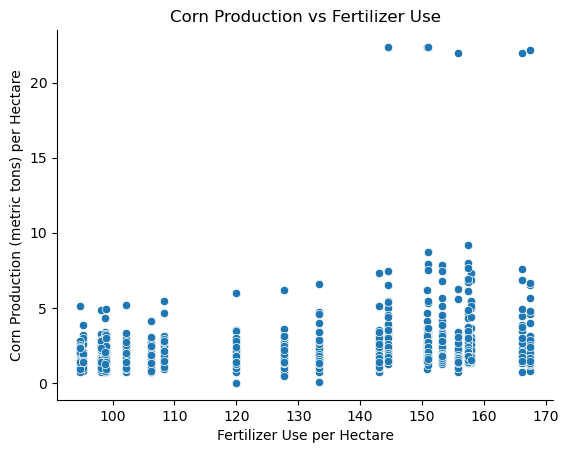

In [67]:
# Re-check for outliers
# Graphs shows production rate has six outliers
preparation_scatterplot = sns.scatterplot(data = clean_crop, x = "Fertilizer/Ha",  y = "Yield/Ha")
preparation_scatterplot.set(xlabel = "Fertilizer Use per Hectare", ylabel = "Corn Production (metric tons) per Hectare",
            title = "Corn Production vs Fertilizer Use")
sns.despine()
plt.show()

In [69]:
# Check for patterns to explain why production outliers are much higher in value
# All outliers are from Delhi state from 2009 to 2014 
filter2_crop[(filter2_crop["Yield/Ha"] > 10)]

,Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Yield/Ha,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha
14394,2009,Kharif,Delhi,48.0,1054,528.400000,7479.36,8.16,21.96,21.958333,11.008333,155.82,0.17
14437,2010,Kharif,Delhi,40.0,878,989.500000,6644.40,9.60,21.95,21.950000,24.737500,166.11,0.24
14444,2011,Kharif,Delhi,38.0,843,641.395455,6365.76,12.54,22.18,22.184211,16.878828,167.52,0.33
14493,2012,Kharif,Delhi,37.0,828,451.900000,5579.60,11.47,22.38,22.378378,12.213514,150.80,0.31
14578,2013,Kharif,Delhi,37.0,828,706.800000,5346.13,9.99,22.38,22.378378,19.102703,144.49,0.27
14623,2014,Kharif,Delhi,35.0,783,416.400000,5283.60,11.55,22.37,22.371429,11.897143,150.96,0.33


In [71]:
# Check median production rate value for Delhi
delhi = filter2_crop[(filter2_crop["State"] == "Delhi")]
delhi["Yield/Ha"].median()

2.2020132692747656

Since the median production rate for Delhi is much lower than the six outliers, I decided to deletes the outliers values.

In [75]:
# Drop six outliers with production rate over 20
clean2_crop = clean_crop[(clean_crop["Yield/Ha"] < 20)]

<hr style="border:2px solid black">

## Part 2c: Data Preparation - Combined Data Set

In [77]:
# Merge together cleaned up weather and crop data sets via "Year" and "Season" columns
combined_df = pd.merge(combined_weather_df, clean2_crop, on=['Year', 'Season'], how='outer')
combined_df = combined_df.drop("Year", axis = 1) # Remove year column
combined_df

,Season,Sown_Temp,Growing_Temp,Harvest_Temp,Yield/Ha,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha
0,Kharif,28.17,27.363333,25.645,0.766080,0.106755,95.17,0.31
1,Kharif,28.17,27.363333,25.645,2.766787,0.002519,95.17,0.31
2,Kharif,28.17,27.363333,25.645,1.448501,0.222311,95.17,0.31
3,Kharif,28.17,27.363333,25.645,2.594231,0.003040,95.17,0.31
4,Kharif,28.17,27.363333,25.645,1.217000,0.003477,95.17,0.31
...,...,...,...,...,...,...,...,...
646,Rabi,24.20,24.605000,29.820,1.981238,0.323096,157.44,0.38
647,Rabi,24.20,24.605000,29.820,6.900995,0.004877,157.44,0.38
648,Rabi,24.20,24.605000,29.820,1.558879,1.554579,157.44,0.38
649,Rabi,24.20,24.605000,29.820,3.001741,0.047295,157.44,0.38


### Reexamine Graphical Analysis with Cleaned Data Set:

In [80]:
clean2_crop.groupby(["Season"]).median()

,Year,Yield/Ha,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha
Season,,,,,
Kharif,2007.0,1.779995,0.016598,133.40,0.26
Rabi,2010.0,2.534423,0.017917,144.49,0.27


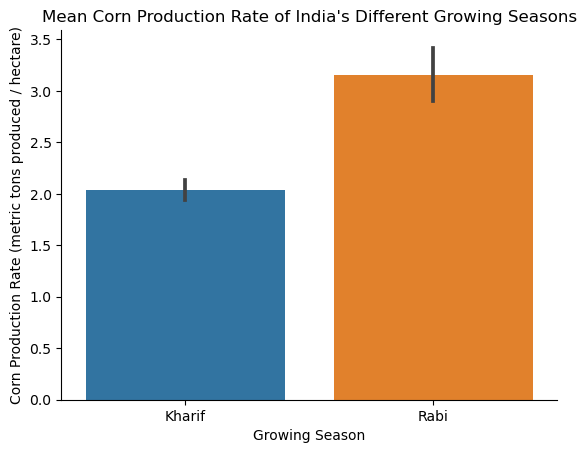

In [86]:
# Seaborn barplot comparing corn production rate across India's growing seasons
with warnings.catch_warnings():
    warnings.simplefilter('ignore') # Ignore warning message that appears.
    season2_barplot = sns.barplot(data = combined_df, x = "Season", y = "Yield/Ha", palette = {"Kharif": "C0", "Rabi": "C1"})
    season2_barplot.set(xlabel = "Growing Season", ylabel = "Corn Production Rate (metric tons produced / hectare)",
            title = "Mean Corn Production Rate of India's Different Growing Seasons")
    sns.despine()
    plt.show()

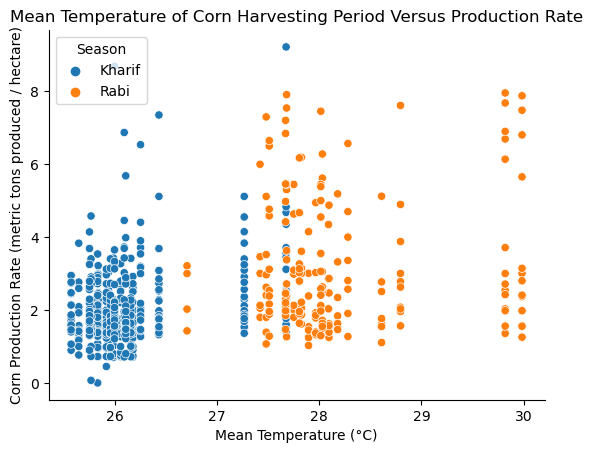

In [90]:
# Scatter plot comparing the mean harvest temperature with production rate
harvest_scatterplot = sns.scatterplot(data = combined_df, x = "Harvest_Temp",  y = "Yield/Ha", hue = "Season")
harvest_scatterplot.set(xlabel = "Mean Temperature (°C)", ylabel = "Corn Production Rate (metric tons produced / hectare)",
            title = "Mean Temperature of Corn Harvesting Period Versus Production Rate")
sns.despine()
plt.show()

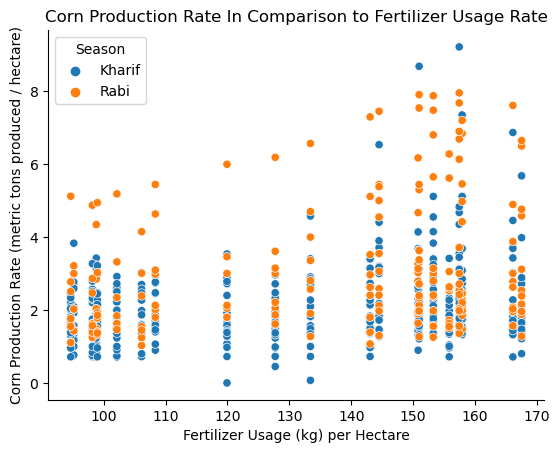

In [94]:
# Scatter plot comparing fertilizer usage per hectare with corn production rate
pesticide2_scatterplot = sns.scatterplot(data = combined_df, x = "Fertilizer/Ha",  y = "Yield/Ha", hue = "Season")
pesticide2_scatterplot.set(xlabel = "Fertilizer Usage (kg) per Hectare", ylabel = "Corn Production Rate (metric tons produced / hectare)",
            title = "Corn Production Rate In Comparison to Fertilizer Usage Rate")
sns.despine()
plt.show()

### Handling Multicollinearity:

In [96]:
# One-hot code season column for Regression Model Preparation
binary_values = {"Kharif": 0, "Rabi": 1}
combined_df["Season"] = combined_df["Season"].map(binary_values) # Replace Kharif and Rabi string values with binary values

# Rearrange columns for final cleaned up data set
final_clean_df = combined_df[[
    "Season", "Sown_Temp", "Growing_Temp", "Harvest_Temp", "Rainfall/Ha", "Fertilizer/Ha", "Pesticide/Ha", "Yield/Ha"]]
final_clean_df

,Season,Sown_Temp,Growing_Temp,Harvest_Temp,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha,Yield/Ha
0,0,28.17,27.363333,25.645,0.106755,95.17,0.31,0.766080
1,0,28.17,27.363333,25.645,0.002519,95.17,0.31,2.766787
2,0,28.17,27.363333,25.645,0.222311,95.17,0.31,1.448501
3,0,28.17,27.363333,25.645,0.003040,95.17,0.31,2.594231
4,0,28.17,27.363333,25.645,0.003477,95.17,0.31,1.217000
...,...,...,...,...,...,...,...,...
646,1,24.20,24.605000,29.820,0.323096,157.44,0.38,1.981238
647,1,24.20,24.605000,29.820,0.004877,157.44,0.38,6.900995
648,1,24.20,24.605000,29.820,1.554579,157.44,0.38,1.558879
649,1,24.20,24.605000,29.820,0.047295,157.44,0.38,3.001741


In [98]:
# Correlation coefficient matrix
corr_matrix = final_clean_df.corr()
corr_matrix

,Season,Sown_Temp,Growing_Temp,Harvest_Temp,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha,Yield/Ha
Season,1.000000,-0.986324,-0.964226,0.841800,0.028451,0.126441,0.054562,0.364988
Sown_Temp,-0.986324,1.000000,0.979705,-0.771078,-0.030624,-0.067961,0.030136,-0.334229
Growing_Temp,-0.964226,0.979705,1.000000,-0.688406,-0.029447,-0.037565,0.049110,-0.310579
Harvest_Temp,0.841800,-0.771078,-0.688406,1.000000,0.007405,0.308912,0.311780,0.405519
Rainfall/Ha,0.028451,-0.030624,-0.029447,0.007405,1.000000,-0.059732,0.024134,0.029326
Fertilizer/Ha,0.126441,-0.067961,-0.037565,0.308912,-0.059732,1.000000,0.247484,0.274099
Pesticide/Ha,0.054562,0.030136,0.049110,0.311780,0.024134,0.247484,1.000000,0.194234
Yield/Ha,0.364988,-0.334229,-0.310579,0.405519,0.029326,0.274099,0.194234,1.000000


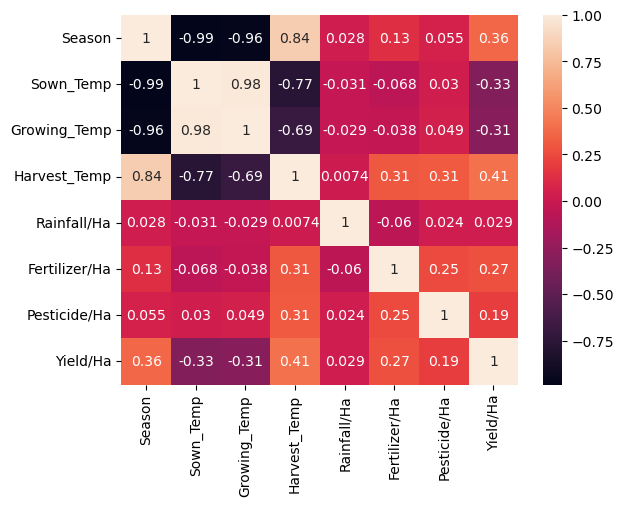

In [100]:
# Correlation matrix heatmap
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [102]:
# Import library for Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [104]:
# Calculate VIFs
X = final_clean_df.iloc[:,:-1]
print(calc_vif(X))


       variables          VIF
0         Season   147.651115
1      Sown_Temp  4148.198278
2   Growing_Temp  9817.975509
3   Harvest_Temp  9163.166099
4    Rainfall/Ha     1.019456
5  Fertilizer/Ha    31.351798
6   Pesticide/Ha    19.088220


In [106]:
# Drop "Season" and "Growing_Temp" variables due to high multicollinearity
final2_clean_df = final_clean_df.drop(["Season", "Growing_Temp"], axis = 1)

In [108]:
# Recheck VIFs
X = final2_clean_df.iloc[:,:]
print(calc_vif(X))

       variables         VIF
0      Sown_Temp   66.456810
1   Harvest_Temp  100.343995
2    Rainfall/Ha    1.017666
3  Fertilizer/Ha   32.202907
4   Pesticide/Ha   17.861046
5       Yield/Ha    4.854771


While still not perfect, VIFs did improve a lot. Multicollinearity will still need to be address during modeling.

In [110]:
final2_clean_df

,Sown_Temp,Harvest_Temp,Rainfall/Ha,Fertilizer/Ha,Pesticide/Ha,Yield/Ha
0,28.17,25.645,0.106755,95.17,0.31,0.766080
1,28.17,25.645,0.002519,95.17,0.31,2.766787
2,28.17,25.645,0.222311,95.17,0.31,1.448501
3,28.17,25.645,0.003040,95.17,0.31,2.594231
4,28.17,25.645,0.003477,95.17,0.31,1.217000
...,...,...,...,...,...,...
646,24.20,29.820,0.323096,157.44,0.38,1.981238
647,24.20,29.820,0.004877,157.44,0.38,6.900995
648,24.20,29.820,1.554579,157.44,0.38,1.558879
649,24.20,29.820,0.047295,157.44,0.38,3.001741


<hr style="border:2px solid black">

## Part 3: Model Building and Evaluation

In [112]:
# Split Data into Training and Testing Sets with "Yield/Ha" as the Target

target = final2_clean_df["Yield/Ha"] # Data subset of target variable that model will predict

# Drop column of "Yield/Ha" target from features data set
features = final2_clean_df.drop(["Yield/Ha"], axis = 1) 

features.shape, target.shape

((651, 5), (651,))

In [114]:
from sklearn.model_selection import train_test_split

# Splits data into 80% training data and 20% test data for both feature variables and target variable data sets
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, 
                                                                            random_state = 42)

# Shape of training and test data sets
print("Training set shape:", features_train.shape, target_train.shape)
print("Test set shape:", features_test.shape, target_test.shape)

Training set shape: (520, 5) (520,)
Test set shape: (131, 5) (131,)


### Linear Regression Model:

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt # square root

# Standardize features using MinMaxScaler
minmax_scale = MinMaxScaler(feature_range = (0, 1))
train_scaled_features = minmax_scale.fit_transform(features_train)

# Create linear regression model
linear_model = LinearRegression()

# Train linear regression model using the feature variables and target variable data sets
linear_model.fit(train_scaled_features, target_train)

# Runs Linear Regression Model using Test data
test_scaled_features = minmax_scale.transform(features_test)
test_prediction = linear_model.predict(test_scaled_features)

# Assessment of Model Fitness Calculations:
# Compares the actual target values with model's predicted target values using features variables test data set
linear_r2 = (r2_score(target_test, test_prediction)) * 100
linear_RMSE = sqrt(mean_squared_error(target_test, test_prediction))
linear_MAE = mean_absolute_error(target_test, test_prediction)

print("Coefficient of Determination (R2):", linear_r2, "%")
print("Root Mean Squared Error (RMSE):", linear_RMSE)
print("Mean Absolute Error (MAE):", linear_MAE)

Coefficient of Determination (R2): 16.115921922776543 %
Root Mean Squared Error (RMSE): 1.2674025322494626
Mean Absolute Error (MAE): 0.8605822350273195


### Ridge Regression Model:

In [120]:
from sklearn.linear_model import Ridge

# Standardize features using MinMaxScaler
minmax_scale = MinMaxScaler(feature_range = (0, 1))
train_scaled_features = minmax_scale.fit_transform(features_train)

# Create ridge regression model
ridge_model = Ridge(alpha = .05)

# Fit ridge regression model using the feature variables and target variable training data sets
ridge_model.fit(train_scaled_features, target_train)

# Runs Ridge Regression Model using Test data
test_scaled_features = minmax_scale.transform(features_test)
r_test_prediction = ridge_model.predict(test_scaled_features)

# Assessment of Model Fitness Calculations:
# Compares the actual target values with model's predicted target values using features variables test data set
ridge_r2 = (r2_score(target_test, r_test_prediction)) * 100
ridge_RMSE = sqrt(mean_squared_error(target_test, r_test_prediction))
ridge_MAE = mean_absolute_error(target_test, r_test_prediction)

print("Coefficient of Determination (R2):", ridge_r2, "%")
print("Root Mean Squared Error (RMSE):", ridge_RMSE)
print("Mean Absolute Error (MAE):", ridge_MAE)

Coefficient of Determination (R2): 16.14098084436819 %
Root Mean Squared Error (RMSE): 1.2672132107853555
Mean Absolute Error (MAE): 0.8604581438828819


### ElasticNet Regression Model

In [123]:
from sklearn.linear_model import ElasticNet

# Standardize features using MinMaxScaler
minmax_scale = MinMaxScaler(feature_range = (0, 1))
train_scaled_features = minmax_scale.fit_transform(features_train)

# Create ElasticNet regression model
enet_model = ElasticNet(alpha = 0.05)

# Train ElasticNet regression model using the feature variables and target variable data sets
enet_model.fit(train_scaled_features, target_train)

# Runs ElasticNet Regression Model using Test data
test_scaled_features = minmax_scale.transform(features_test)
enet_test_prediction = enet_model.predict(test_scaled_features)

# Assessment of Model Fitness Calculations:
# Compares the actual target values with model's predicted target values using features variables test data set
enet_r2 = (r2_score(target_test, enet_test_prediction)) * 100
enet_RMSE = sqrt(mean_squared_error(target_test, enet_test_prediction))
enet_MAE = mean_absolute_error(target_test, enet_test_prediction)


print("Coefficient of Determination (R2):", enet_r2, "%")
print("Root Mean Squared Error (RMSE):", enet_RMSE)
print("Mean Absolute Error (MAE):", enet_MAE)

Coefficient of Determination (R2): 15.497031592242315 %
Root Mean Squared Error (RMSE): 1.272069339842013
Mean Absolute Error (MAE): 0.8682072806606969


In [125]:
evaluation_df = pd.DataFrame({
    "Model": ["Linear", "Ridge", "ElasticNet"],
    "R2": [round(linear_r2, 3), round(ridge_r2, 3), round(enet_r2, 3)],
    "RMSE": [round(linear_RMSE, 3), round(ridge_RMSE, 3), round(enet_RMSE, 3)],
    "MAE": [round(linear_MAE,3 ), round(ridge_MAE, 3), round(enet_MAE, 3)]
})

evaluation_df['R2'] = evaluation_df['R2'].astype(str) + '%'
evaluation_df

,Model,R2,RMSE,MAE
0,Linear,16.116%,1.267,0.861
1,Ridge,16.141%,1.267,0.860
2,ElasticNet,15.497%,1.272,0.868
